In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_percentage_error
import seaborn as sns




dem = pd.read_excel('dem.xlsx')
weath = pd.read_excel('weath.xlsx',skiprows = 3)

dem['timestamp'] = pd.to_datetime(dem['datetime'])
weath['timestamp'] = pd.to_datetime(weath['time'])

dem = dem.sort_values('timestamp')
weath = weath.sort_values('timestamp')

rename_map = {
    'temperature_2m (°C)': 'temperature',
    'apparent_temperature (°C)': 'apparent_temp',
    'relative_humidity_2m (%)': 'humidity',
    'precipitation (mm)': 'precipitation'
}

weath = weath.rename(columns=rename_map)

In [2]:
dem['hour'] = dem['timestamp'].dt.hour

dem['rolling_mean_5d'] = dem.groupby('hour')['demand_mw'].transform(
    lambda x: x.rolling(window=5, min_periods=1, closed='left').mean()
)

dem['rolling_std_5d'] = dem.groupby('hour')['demand_mw'].transform(
    lambda x: x.rolling(window=5, min_periods=2, closed='left').std()
)

dem['upper_bound'] = dem['rolling_mean_5d'] + (3 * dem['rolling_std_5d'])
dem['lower_bound'] = dem['rolling_mean_5d'] - (3 * dem['rolling_std_5d'])

is_outlier = (
    (dem['demand_mw'] > dem['upper_bound']) | 
    (dem['demand_mw'] < dem['lower_bound'])
).fillna(False)

dem['demand_mw'] = np.where(is_outlier, dem['rolling_mean_5d'], dem['demand_mw'])

dem = dem.drop(columns=['hour', 'rolling_mean_5d', 'rolling_std_5d', 'upper_bound', 'lower_bound'])

In [3]:
weath['temperature'] = np.where(
    (weath['temperature'] < 5) | (weath['temperature'] > 45), 
    np.nan, 
    weath['temperature']
)

weath['apparent_temp'] = np.where(
    (weath['apparent_temp'] < 0) | (weath['apparent_temp'] > 55), 
    np.nan, 
    weath['apparent_temp']
)

weath['temperature'] = weath['temperature'].ffill()
weath['apparent_temp'] = weath['apparent_temp'].ffill()

weath['apparent_temp_rolling_mean_24h'] = weath['apparent_temp'].rolling(
    window=24, min_periods=1, closed='left'
).mean()



weath['humidity'] = np.where(
    (weath['humidity'] < 0) | (weath['humidity'] > 100), 
    np.nan, 
    weath['humidity']
)

weath['humidity'] = weath['humidity'].ffill()


weath['precipitation'] = np.where(
    weath['precipitation'] < 0, 
    np.nan, 
    weath['precipitation']
)

weath['precipitation'] = weath['precipitation'].fillna(0)

weath['is_raining'] = (weath['precipitation'] > 0).astype(int)

In [4]:
dem['solar'] = dem['solar'].fillna(0)
dem['wind'] = dem['wind'].fillna(0)

dem['roll_mean_3h'] = dem['demand_mw'].rolling(window=3).mean()
dem['roll_mean_24h'] = dem['demand_mw'].rolling(window=24).mean()
dem['roll_std_24h'] = dem['demand_mw'].rolling(window=24).std()
dem['roll_max_24h'] = dem['demand_mw'].rolling(window=24).max()



weath['temp_roll_mean_6h'] = weath['temperature'].rolling(window=6).mean()
weath['temp_roll_mean_24h'] = weath['temperature'].rolling(window=24).mean()
weath['precip_roll_sum_12h'] = weath['precipitation'].rolling(window=12).sum()

feature_cols1 = [col for col in dem.columns if 'roll' in col or 'lag' in col]
feature_cols2 = [col for col in weath.columns if 'roll' in col or 'lag' in col]
dem = dem.dropna(subset=feature_cols1)
weath = weath.dropna(subset=feature_cols2)


In [5]:
start_date = '2015-05-01 00:00:00'
dem = dem[dem['timestamp'] >= start_date]
weath = weath[weath['timestamp'] >= start_date]
full= pd.merge(dem, weath, on='timestamp', how='inner')

full = full.sort_values('timestamp').reset_index(drop=True)

full['hour'] = full['timestamp'].dt.hour
full['day_of_week'] = full['timestamp'].dt.dayofweek
full['month'] = full['timestamp'].dt.month
full['year'] = full['timestamp'].dt.year
full['quarter'] = full['timestamp'].dt.quarter
full['is_month_start'] = full['timestamp'].dt.is_month_start.astype(int)
full['is_month_end'] = full['timestamp'].dt.is_month_end.astype(int)

full['is_weekend'] = full['day_of_week'].map(lambda x: 1 if x >= 5 else 0)

In [6]:
full['demand_lag_1h'] = full['demand_mw'].shift(1)
full['demand_lag_2h'] = full['demand_mw'].shift(2)

full['demand_lag_24h'] = full['demand_mw'].shift(24)
full['demand_lag_168h'] = full['demand_mw'].shift(168)


full['target_demand_next_hour'] = full['demand_mw'].shift(-1)

In [7]:
eco = pd.read_csv('eco.csv')

eco = eco[(eco['Indicator Name']=='GDP per person employed (constant 2021 PPP $)') | (eco['Indicator Name']=='GDP per capita growth (annual %)')|(eco['Indicator Name']=='GDP growth (annual %)')
          |(eco['Indicator Name']=='Electric power consumption (kWh per capita)')]
year_cols = [col for col in eco.columns if (col != 'Country Name') & (col != 'Indicator Name') & (col != 'Indicator Code' )]


cols_to_drop = [col for col in year_cols if (int(col) in range(2015))]
eco = eco.drop(columns=cols_to_drop)
eco = eco.dropna(axis=1, how='all')
eco = eco.drop(columns=["Indicator Code","Country Name"])
eco


,Indicator Name,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1076,GDP per capita growth (annual %),5.604495,6.161816,5.687103,6.441975,6.972644,2.586478,6.070694,6.008475,4.490704,2.964998
1078,GDP growth (annual %),6.552640,7.113478,6.590250,7.319413,7.881915,3.448018,6.938679,7.099829,5.775112,4.223259
1404,GDP per person employed (constant 2021 PPP $),14411.374850,15254.590780,15398.445430,16161.757650,17073.963590,17564.354760,18166.590590,18760.024000,19552.116860,20762.815660
1494,Electric power consumption (kWh per capita),348.932681,412.780315,443.212946,471.126089,515.101730,509.945927,574.118203,602.674747,NaN,NaN


In [8]:
eco_melted = eco.melt(
    id_vars=['Indicator Name'], 
    var_name='Year', 
    value_name='Value'
)
eco_melted['Year'] = eco_melted['Year'].astype(int)

eco_pivoted = eco_melted.pivot(
    index='Year', 
    columns='Indicator Name', 
    values='Value'
).reset_index()

eco_pivoted.columns.name = None

rename_map2 = {
    'Year' : 'year',
    'Electric power consumption (kWh per capita)' : 'power consumption',
    'GDP growth (annual %)': 'GDP growth',
    'GDP per capita growth (annual %)': 'GDP per capita growth',
    'GDP per person employed (constant 2021 PPP $)': 'GDP per employed'
}


econo = eco_pivoted.rename(columns=rename_map2)
econo['merge_year'] = econo['year'] + 1
econo_lagged = econo.drop(columns=['year'])


new_eco_cols = ['power consumption', 'GDP growth', 'GDP per capita growth', 'GDP per employed']

full = full.drop(columns=[col for col in new_eco_cols if col in full.columns], errors='ignore')

full = pd.merge(full, econo_lagged, left_on='year', right_on='merge_year', how='left')

lag_cols = [col for col in full.columns if 'lag' in col]
full = full.dropna(subset=lag_cols)
full = full.drop(columns=['merge_year'])
full = full.drop(columns=['power consumption'])
full = full.dropna(subset=['GDP growth', 'GDP per capita growth','GDP per employed'])
full

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,...,is_month_end,is_weekend,demand_lag_1h,demand_lag_2h,demand_lag_24h,demand_lag_168h,target_demand_next_hour,GDP growth,GDP per capita growth,GDP per employed
5908,2016-01-01 00:00:00,4140.0,4140.0,0,3734,113,0,40,0.0,0.0,...,0,0,4688.0,5023.0,3505.0,3722.0,3941.0,6.552640,5.604495,14411.37485
5909,2016-01-01 01:00:00,3941.0,3941.0,0,3551,113,0,35,0.0,0.0,...,0,0,4140.0,4688.0,3502.0,3628.0,3724.0,6.552640,5.604495,14411.37485
5910,2016-01-01 02:00:00,3724.0,3724.0,0,3286,133,0,35,0.0,0.0,...,0,0,3941.0,4140.0,3451.0,3544.0,3603.0,6.552640,5.604495,14411.37485
5911,2016-01-01 03:00:00,3603.0,3603.0,0,3168,130,0,35,0.0,0.0,...,0,0,3724.0,3941.0,3793.0,3471.0,3590.0,6.552640,5.604495,14411.37485
5912,2016-01-01 04:00:00,3590.0,3590.0,0,3135,140,0,35,0.0,0.0,...,0,0,3603.0,3724.0,4172.0,3671.0,3590.0,6.552640,5.604495,14411.37485
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88218,2025-06-17 08:00:00,11896.0,11896.0,0,5678,490,3470,132,219.0,57.0,...,0,0,11745.0,11805.0,12876.0,11642.0,12290.0,4.223259,2.964998,20762.81566
88219,2025-06-17 09:00:00,12290.0,12290.0,0,6065,531,3491,132,203.0,16.0,...,0,0,11896.0,11745.0,13155.0,11635.0,12443.0,4.223259,2.964998,20762.81566
88220,2025-06-17 10:00:00,12443.0,12443.0,0,5900,552,3601,172,215.0,31.0,...,0,0,12290.0,11896.0,13569.0,11539.0,12826.0,4.223259,2.964998,20762.81566
88221,2025-06-17 11:00:00,12826.0,12826.0,0,5896,595,3591,172,324.0,37.0,...,0,0,12443.0,12290.0,13816.0,11761.0,13139.0,4.223259,2.964998,20762.81566


In [9]:
split_date = '2024-01-01'
end_date = '2025-01-01'
train = full[full['timestamp'] < split_date].copy()
test = full[(full['timestamp'] >= split_date )&(full['timestamp'] < end_date)].copy()
test = test[test['year'] != 2023]
test

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,...,is_month_end,is_weekend,demand_lag_1h,demand_lag_2h,demand_lag_24h,demand_lag_168h,target_demand_next_hour,GDP growth,GDP per capita growth,GDP per employed
75419,2024-01-01 00:00:00,7580.0,7580.0,0,3936,0,2887,86,0.0,0.0,...,0,0,8039.0,8690.0,7601.0,8079.0,7259.0,5.775112,4.490704,19552.11686
75420,2024-01-01 01:00:00,7259.0,7259.0,0,3781,0,2720,86,0.0,10.0,...,0,0,7580.0,8039.0,7385.0,7624.0,7010.0,5.775112,4.490704,19552.11686
75421,2024-01-01 02:00:00,7010.0,7010.0,0,3659,0,2595,86,0.0,10.0,...,0,0,7259.0,7580.0,7123.0,7288.0,6733.0,5.775112,4.490704,19552.11686
75422,2024-01-01 03:00:00,6733.0,6733.0,0,3421,0,2566,86,0.0,5.0,...,0,0,7010.0,7259.0,6791.0,6975.0,6598.0,5.775112,4.490704,19552.11686
75423,2024-01-01 04:00:00,6598.0,6598.0,0,3304,0,2535,86,0.0,1.0,...,0,0,6733.0,7010.0,6752.0,6844.0,6936.0,5.775112,4.490704,19552.11686
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84197,2024-12-31 19:00:00,10228.0,10228.0,0,5040,248,3144,46,0.0,14.0,...,1,0,10266.0,10380.0,10283.0,10073.0,9962.0,5.775112,4.490704,19552.11686
84198,2024-12-31 20:00:00,9962.0,9962.0,0,4901,162,3110,46,0.0,8.0,...,1,0,10228.0,10266.0,10001.0,9935.0,9574.0,5.775112,4.490704,19552.11686
84199,2024-12-31 21:00:00,9574.0,9574.0,0,4887,101,2847,46,0.0,10.0,...,1,0,9962.0,10228.0,9652.0,9318.0,9122.0,5.775112,4.490704,19552.11686
84200,2024-12-31 22:00:00,9122.0,9122.0,0,4787,33,2630,46,0.0,17.0,...,1,0,9574.0,9962.0,8980.0,8889.0,8480.0,5.775112,4.490704,19552.11686


In [10]:
train_clean = train.dropna(subset=['target_demand_next_hour']).copy()
test_clean = test.dropna(subset=['target_demand_next_hour']).copy()

cols_to_drop = [
    'datetime', 'timestamp', 'time', 'remarks', 
    'target_demand_next_hour'
]

existing_drops = [col for col in cols_to_drop if col in train_clean.columns]

X_train = train_clean.drop(columns=existing_drops)
y_train = train_clean['target_demand_next_hour']

X_test = test_clean.drop(columns=existing_drops)
y_test = test_clean['target_demand_next_hour']


xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

print("Training model")

xgb_model.fit(X_train, y_train)

predictions = xgb_model.predict(X_test)
mape = mean_absolute_percentage_error(y_test, predictions)

print(f"\nFinal Test MAPE (2024): {mape * 100:.2f}%")



Training model

Final Test MAPE (2024): 2.58%


/var/folders/6x/r6rgv3nd7fn0bjk37xbkd7k00000gn/T/ipykernel_2989/1450534555.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


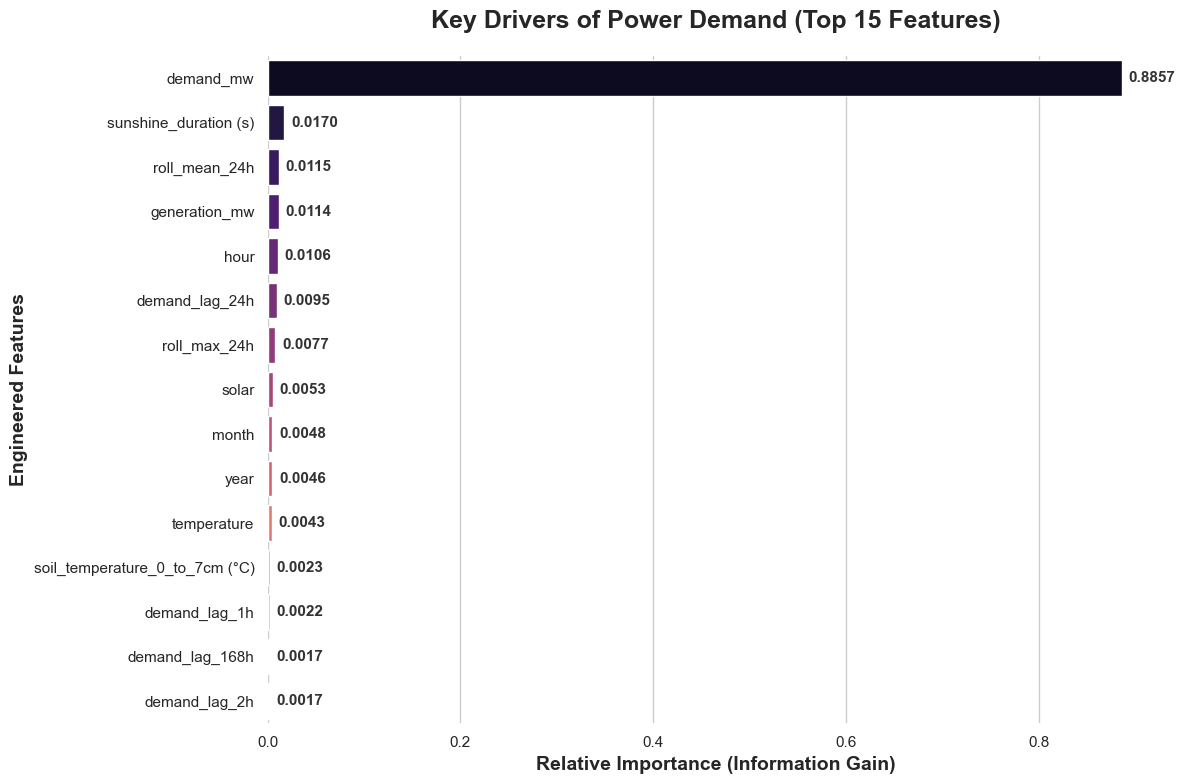

In [11]:
#ONLY TOP 15 FEATURES ARE SHOWN IN THE PLOT


importances = xgb_model.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df,
    palette='magma' 
)

plt.title('Key Drivers of Power Demand (Top 15 Features)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Relative Importance (Information Gain)', fontsize=14, fontweight='bold')
plt.ylabel('Engineered Features', fontsize=14, fontweight='bold')

for p in ax.patches:
    ax.annotate(f'{p.get_width():.4f}',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold',
                color='#333333')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()